<a href="https://colab.research.google.com/github/raflymuhammad969-pixel/tugas-visi-komputer/blob/main/Pertemuan%206.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

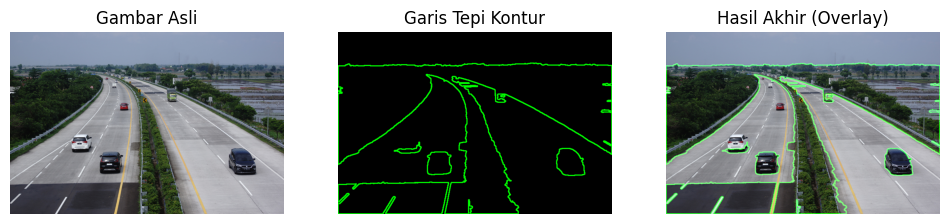

In [12]:
# Baca gambar
image = cv2.imread('tol.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Blur untuk mengurangi noise
blur = cv2.GaussianBlur(gray, (5,5), 0)

# Threshold (segmentasi)
_, thresh = cv2.threshold(blur, 127, 255, cv2.THRESH_BINARY_INV)

# Cari kontur (bentuk objek)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Canvas kosong untuk garis tepi
edge_mask = np.zeros_like(image_rgb)

# Gambar kontur sebagai garis tepi
for cnt in contours:
    area = cv2.contourArea(cnt)

    # Hilangkan noise kecil
    if area < 500:
        continue

    # Gambar garis tepi (bukan fill)
    cv2.drawContours(edge_mask, [cnt], -1, (0,255,0), 2)

# Tambahan: Edge detection (lebih detail)
edges = cv2.Canny(blur, 100, 200)

# Ubah edge ke RGB biar bisa digabung
edges_rgb = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)

# Gabungkan hasil
result = cv2.addWeighted(image_rgb, 1, edge_mask, 1, 0)

# Tampilkan hasil
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.title("Gambar Asli")
plt.imshow(image_rgb)
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Garis Tepi Kontur")
plt.imshow(edge_mask)
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Hasil Akhir (Overlay)")
plt.imshow(result)
plt.axis('off')

plt.show()